                                            Importing Python Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

                                    DATA ANALYSIS PYTHON PROJECT - BLINKIT ANALYSIS

In [2]:
# Importing the data through Pandas
DF = pd.read_csv("Blinkit_sales_data_Cleaned (2).csv")

# Overview of data 

DF.head(10)

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Total Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2010,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2000,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0
5,low fat,FDS52,Frozen Foods,2020,OUT017,Tier 2,Small,Supermarket Type1,0.005505,8.89,102.4016,5.0
6,Low Fat,NCU05,Health and Hygiene,2011,OUT010,Tier 3,Small,Grocery Store,0.098312,11.80,81.4618,5.0
7,Low Fat,NCD30,Household,2015,OUT045,Tier 2,Small,Supermarket Type1,0.026904,19.70,96.0726,5.0
8,Low Fat,FDW20,Fruits and Vegetables,2000,OUT013,Tier 3,High,Supermarket Type1,0.024129,20.75,124.1730,5.0
9,Low Fat,FDX25,Canned,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.101562,NaN,181.9292,5.0


In [3]:
                              #                  DATA CLEANING                      

In [4]:
# Rows and Coluumns 
DF.shape

'''  (8523, 18)  Rows and Columns   '''

# Mean,Median and Mode and some other figures
DF.describe()

# INformation about the data 
DF.info()

<class 'pandas.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item Fat Content           8523 non-null   str    
 1   Item Identifier            8523 non-null   str    
 2   Item Type                  8523 non-null   str    
 3   Outlet Establishment Year  8523 non-null   int64  
 4   Outlet Identifier          8523 non-null   str    
 5   Outlet Location Type       8523 non-null   str    
 6   Outlet Size                8523 non-null   str    
 7   Outlet Type                8523 non-null   str    
 8   Item Visibility            8523 non-null   float64
 9   Item Weight                7060 non-null   float64
 10  Total Sales                8523 non-null   float64
 11  Rating                     8523 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 799.2 KB


In [5]:
DF['Item Fat Content'].unique()

<StringArray>
['Regular', 'Low Fat', 'low fat', 'LF', 'reg']
Length: 5, dtype: str

In [6]:
''' SOLUTION '''

DF['Item Fat Content'] = DF['Item Fat Content'].replace({'LF' : 'Low Fat',
                                                         'low fat' : 'Low Fat',
                                                         'reg': 'Regular',
                                                         })

In [7]:
''' validating '''

DF['Item Fat Content'].unique()

<StringArray>
['Regular', 'Low Fat']
Length: 2, dtype: str

In [8]:
'''  Checking nulls '''

DF['Item Weight'].isnull()

0       False
1       False
2       False
3       False
4       False
        ...  
8518     True
8519     True
8520     True
8521     True
8522     True
Name: Item Weight, Length: 8523, dtype: bool

In [9]:
'''' FIXING NULLS '''

''' Filling null values through Group wise mean of item type'''
DF['Item Weight'] = DF['Item Weight'].fillna(
    DF.groupby('Item Type')['Item Weight'].transform('mean')
)

In [10]:
''' Validating '''

DF['Item Weight'].isnull()

0       False
1       False
2       False
3       False
4       False
        ...  
8518    False
8519    False
8520    False
8521    False
8522    False
Name: Item Weight, Length: 8523, dtype: bool

                                   BUSINESS REQUIREMENTS

KPI Requirements

In [11]:
# Total sales

Total_sales = round(DF['Total Sales'].sum(),2)

print(f"Total_Sales --> ${Total_sales:,.1f}")

Total_Sales --> $1,201,681.5


In [12]:
#Average sales

Average_Sales = round(DF['Total Sales'].mean(),2)

print(f"Average sales ---> ${Average_Sales:,.2f}")

Average sales ---> $140.99


In [13]:
# Number of items

Total_items = DF['Item Identifier'].count()

print('Total number if items --> ', Total_items)

Total number if items -->  8523


In [14]:
# Average rating 

Average_rating = round(DF['Rating'].mean(),2)

print("Average rating --> ", Average_rating)

Average rating -->  3.97


Granular Requirements

                 Total Sales by Fat Content

In [15]:
''' SALES BY FAT CONTENT '''

sales_by_fat_content = round(DF.groupby('Item Fat Content')['Total Sales'].sum(),2)

print(" sales by fat content -->", sales_by_fat_content)

 sales by fat content --> Item Fat Content
Low Fat    776319.68
Regular    425361.80
Name: Total Sales, dtype: float64


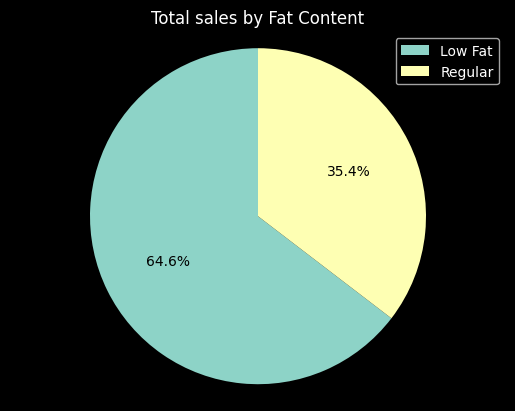

In [16]:
''' PIE CHART '''

plt.pie(sales_by_fat_content, labels = sales_by_fat_content.index, autopct= '%.1f%%', startangle = 90,textprops= {'color' : 'Black'})

plt.title('Total sales by Fat Content')
plt.legend()
plt.axis('equal')
plt.show()

                    Total Sales by Item Type:


In [17]:
Total_Sales_by_item_type = round(DF.groupby('Item Type')['Total Sales'].sum().sort_values(ascending= False),2)

print('Total sales by the type if items --> ', Total_Sales_by_item_type)

Total sales by the type if items -->  Item Type
Fruits and Vegetables    178124.08
Snack Foods              175433.92
Household                135976.53
Frozen Foods             118558.88
Dairy                    101276.46
Canned                    90706.73
Baking Goods              81894.74
Health and Hygiene        68025.84
Meat                      59449.86
Soft Drinks               58514.16
Breads                    35379.12
Hard Drinks               29334.68
Others                    22451.89
Starchy Foods             21880.03
Breakfast                 15596.70
Seafood                    9077.87
Name: Total Sales, dtype: float64


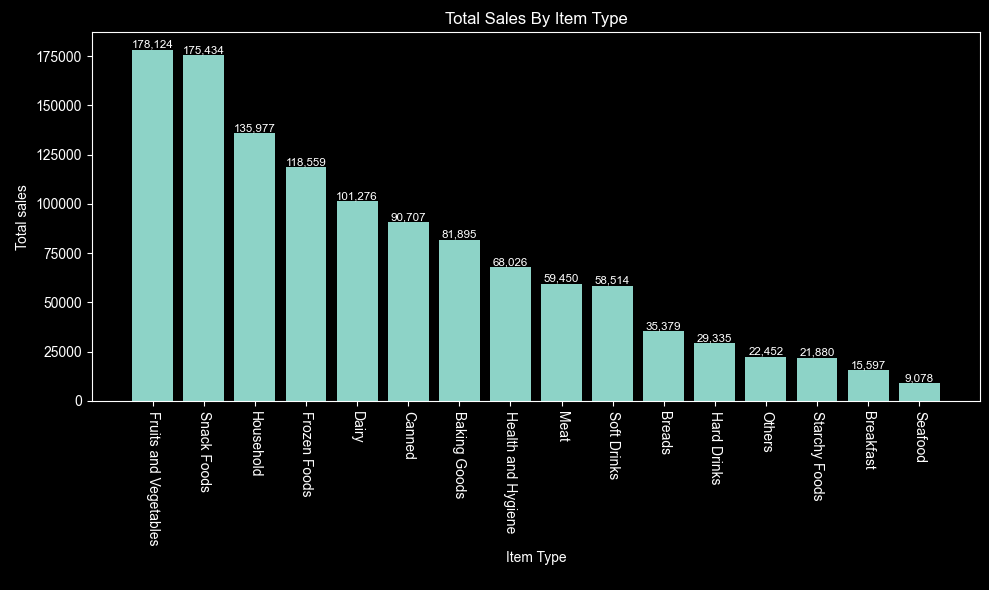

In [18]:
''' Bar Chart '''

plt.figure(figsize= (10,6))

bars = plt.bar(Total_Sales_by_item_type.index, Total_Sales_by_item_type.values)

plt.xticks(rotation = -90)
plt.xlabel('Item Type')
plt.ylabel('Total sales')

plt.title('Total Sales By Item Type')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             f"{bar.get_height():,.0f}", ha = "center", va = "bottom", fontsize = 8.4)
    
plt.tight_layout()
plt.style.use('seaborn-v0_8-darkgrid')
# sns.set_palette('dark')

plt.show()

Fat Content by Outlet for Total Sales:


In [19]:
Total_sales_by_outlet_segmanted_by_fat_contnet = DF.groupby(['Outlet Location Type','Item Fat Content'])['Total Sales'].sum().unstack()



print("Total sales by Outlet location segmented by Fat Content", Total_sales_by_outlet_segmanted_by_fat_contnet)



Total sales by Outlet location segmented by Fat Content Item Fat Content          Low Fat      Regular
Outlet Location Type                          
Tier 1                215047.9126  121349.8994
Tier 2                254464.7734  138685.8682
Tier 3                306806.9924  165326.0348


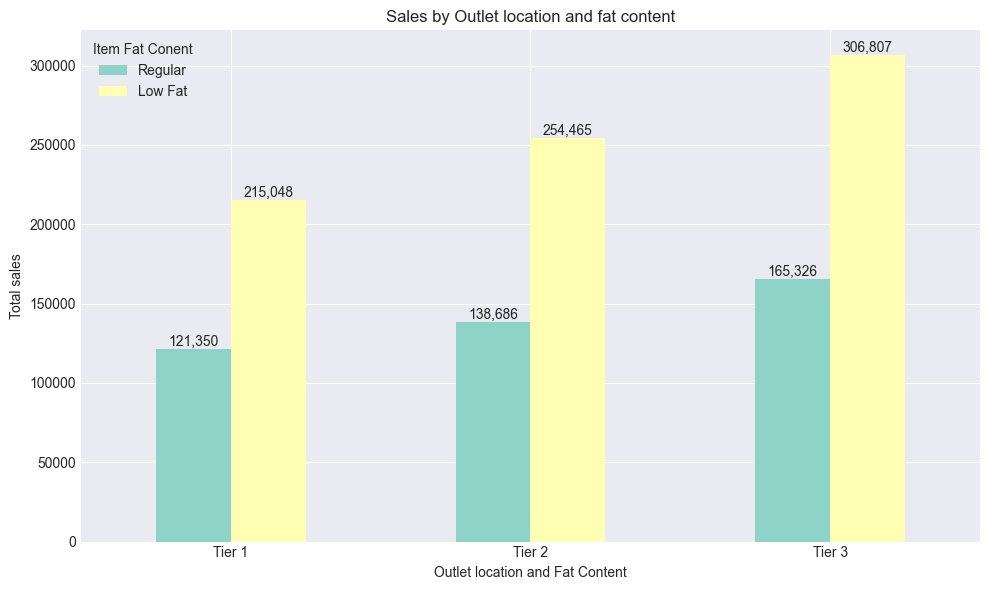

In [20]:
''' Bar Chart '''

Total_sales_by_outlet_segmanted_by_fat_contnet = Total_sales_by_outlet_segmanted_by_fat_contnet[['Regular', 'Low Fat']]

ax = Total_sales_by_outlet_segmanted_by_fat_contnet.plot(kind = 'bar', figsize = (10,6), title = 'Sales by Outlet location and fat content')

plt.legend(title = 'Item Fat Conent')
plt.xlabel("Outlet location and Fat Content")
plt.ylabel("Total sales")
plt.xticks(rotation = 0)

for container in ax.containers :
    for bar in container:
       ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             f"{bar.get_height():,.0f}", ha = "center", va = "bottom",fontsize = 10) 
    
    
plt.tight_layout()

# plt.style('seaborn-v0_8-darkgrid')
plt.show()    


Total sales by Outlet Establishment 

In [ ]:
Total_sales_by_outlet_establishment = DF.groupby('Outlet Establishment Year')['Total Sales'].sum().sort_index()

print('Total sales by outlet establishment year', Total_sales_by_outlet_establishment)

Total sales by outlet establishment year Outlet Establishment Year
1998    204522.2570
2000    131809.0156
2010    132113.3698
2011     78131.5646
2012    130476.8598
2015    130942.7782
2017    133103.9070
2020    129103.9564
2022    131477.7724
Name: Total Sales, dtype: float64


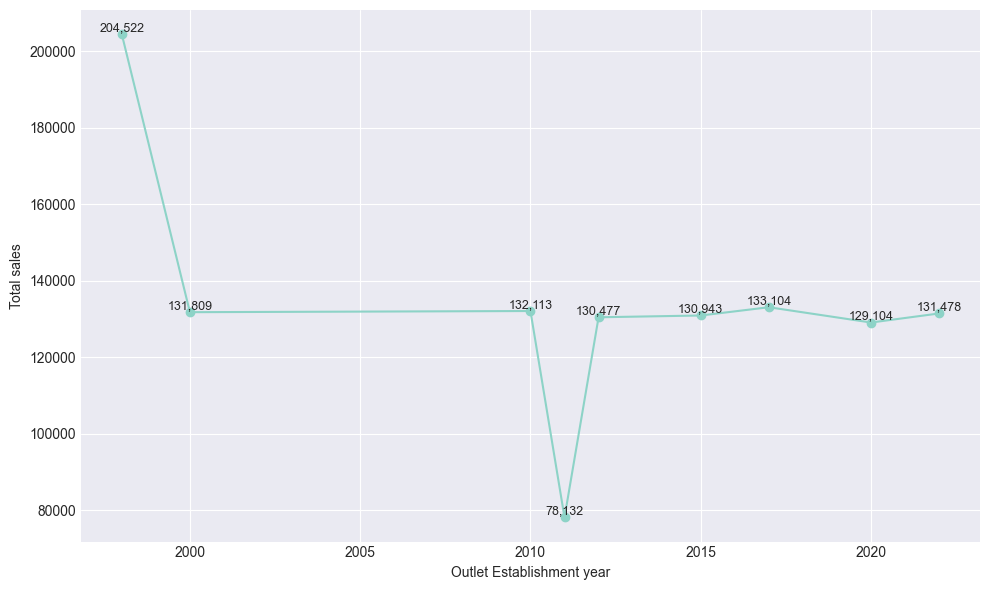

In [48]:



plt.figure(figsize = (10,6))

plt.plot(Total_sales_by_outlet_establishment.index, Total_sales_by_outlet_establishment.values, marker = 'o', linestyle='-')

plt.xlabel('Outlet Establishment year')
plt.ylabel('Total sales')

plt.xticks(rotation = 0)

for x, y in zip(
    Total_sales_by_outlet_establishment.index, 
    Total_sales_by_outlet_establishment.values
):
    plt.text(x, y, f"{y:,.0f}", ha = 'center', va = 'bottom', fontsize = 9 )




plt.tight_layout()

# plt.style.use("seaborn_v0-8")

plt.show()




Percentage of Sales by Outlet Size

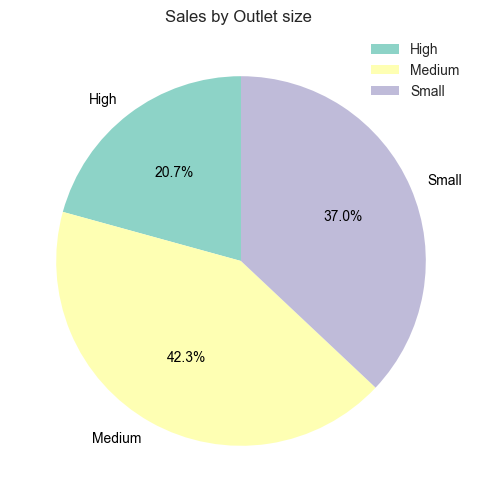

In [57]:
Sales_by_outlet_size = round(DF.groupby('Outlet Size')['Total Sales'].sum(),2)



plt.figure(figsize = (9,6))

plt.pie(Sales_by_outlet_size, labels = Sales_by_outlet_size.index, autopct="%1.1f%%", startangle= 90, textprops = {'color' : 'black'})

plt.title('Sales by Outlet size ')
plt.legend()

plt.show()

Sales by Outlet Location:


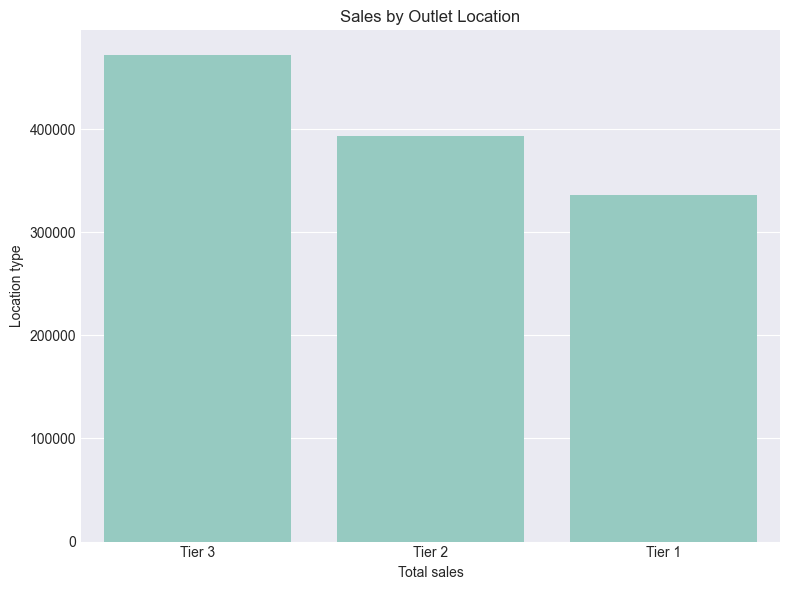

In [65]:
Sales_by_outlet_location = DF.groupby('Outlet Location Type')['Total Sales'].sum().reset_index()
Sales_by_outlet_location = Sales_by_outlet_location.sort_values("Total Sales", ascending = False)

plt.figure(figsize = (8,6))

ax = sns.barplot(x = 'Outlet Location Type', y = 'Total Sales',data = Sales_by_outlet_location)

plt.title("Sales by Outlet Location")

plt.xlabel("Total sales")
plt.ylabel("Location type")

plt.tight_layout()   # it ensures layout does not need scrolling 

plt.show()

